**REGRESIÓN LINEAL 2 - EJERCICIOS**

---



**Problema 2-EdadSeguros.csv**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import statsmodels.api as sm

In [3]:
df = pd.read_csv("EdadSeguros.csv")

print(df.head())
print(df.info())

   Edad  Costo
0    18     22
1    22     24
2    23     55
3    25     27
4    27     85
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Edad    80 non-null     int64
 1   Costo   80 non-null     int64
dtypes: int64(2)
memory usage: 1.4 KB
None


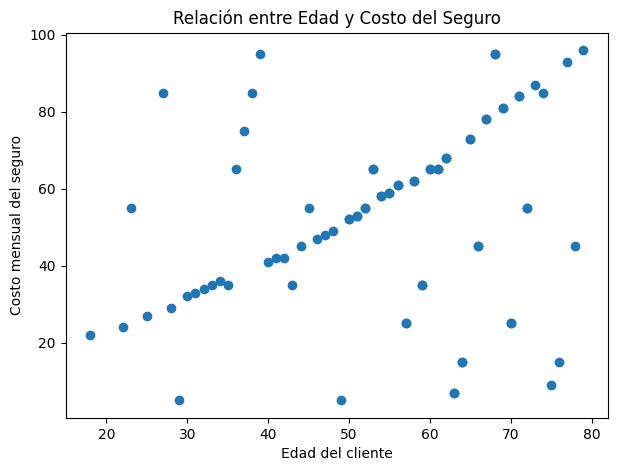

In [4]:
plt.figure(figsize=(7,5))

plt.scatter(df["Edad"], df["Costo"])

plt.xlabel("Edad del cliente")
plt.ylabel("Costo mensual del seguro")
plt.title("Relación entre Edad y Costo del Seguro")

plt.show()

In [5]:
X = df[['Edad']]
y = df['Costo']

In [6]:
modelo = LinearRegression()
modelo.fit(X,y)

LinearRegression()

In [7]:
pendiente = modelo.coef_[0]
intercepto = modelo.intercept_

print("Pendiente:", pendiente)
print("Intercepto:", intercepto)

print(f"Ecuación: Costo = {pendiente:.2f} * Edad + {intercepto:.2f}")

Pendiente: 0.4607049329271551
Intercepto: 27.399609855165416
Ecuación: Costo = 0.46 * Edad + 27.40


In [8]:
y_pred = modelo.predict(X)

In [9]:
X_sm = sm.add_constant(X)

modelo_sm = sm.OLS(y, X_sm).fit()

predicciones = modelo_sm.get_prediction(X_sm)

intervalos = predicciones.summary_frame(alpha=0.05)

print(intervalos.head())

        mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0  35.692299  6.595432      22.561802      48.822795    -12.329087   
1  37.535118  5.977596      25.634638      49.435599    -10.164619   
2  37.995823  5.825246      26.398649      49.592998     -9.629149   
3  38.917233  5.523567      27.920656      49.913810     -8.565060   
4  39.838643  5.226495      29.433490      50.243796     -7.510177   

   obs_ci_upper  
0     83.713684  
1     85.234856  
2     85.620795  
3     86.399527  
4     87.187463  


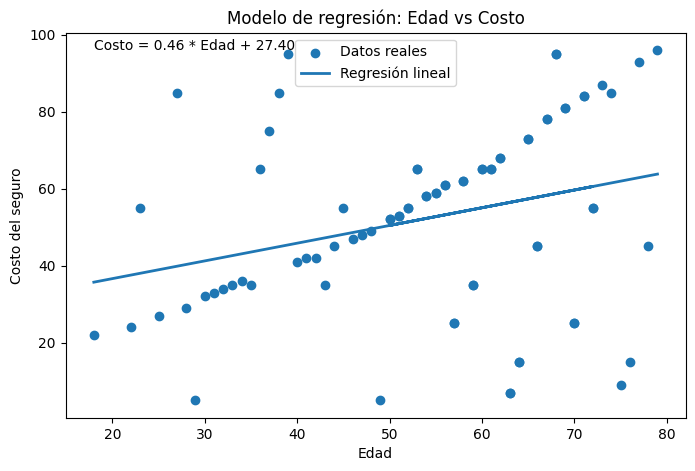

In [10]:
plt.figure(figsize=(8,5))

plt.scatter(X, y, label="Datos reales")

plt.plot(X, y_pred, linewidth=2, label="Regresión lineal")

plt.xlabel("Edad")
plt.ylabel("Costo del seguro")
plt.title("Modelo de regresión: Edad vs Costo")

ecuacion = f"Costo = {pendiente:.2f} * Edad + {intercepto:.2f}"
plt.text(min(X.values), max(y), ecuacion)

plt.legend()

plt.show()

In [11]:
edades = pd.DataFrame({'Edad':[30,40,50,60]})

predicciones = modelo.predict(edades)

tabla_predicciones = pd.DataFrame({
    "Edad": edades["Edad"],
    "Costo_estimado": predicciones
})

tabla_predicciones

,Edad,Costo_estimado
0,30,41.220758
1,40,45.827807
2,50,50.434857
3,60,55.041906
